## 3.Modeling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

from statsmodels.tsa.stattools import adfuller

from sktime.forecasting.var import VAR
from sktime.utils.plotting import plot_series
from prophet import Prophet

In [2]:
df = pd.read_csv('../data/cleared-combine-21-23.csv', index_col='time', parse_dates=True)
df.index.freq = 'h'
df.head()

,isholiday,temp,dwpt,rhum,prcp,wdir,wspd,pres,coco,771826,...,767351,717819,717823,767367,717825,717827,771808,771767,772011,772024
time,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,1,17.8,0.0,30.0,0.0,350.0,24.1,1013.0,2.0,690.0,...,1391.0,1147.0,1072.0,1407.0,1142.0,1107.0,2530.0,3291.0,675.0,743.0
2021-01-01 01:00:00,1,16.7,-0.1,32.0,0.0,340.0,24.1,1013.1,2.0,793.0,...,1537.0,1248.0,1151.0,1445.0,1190.0,1140.0,2655.0,3487.0,733.0,801.0
2021-01-01 02:00:00,1,16.1,-0.6,32.0,0.0,330.0,25.9,1013.9,2.0,463.0,...,1164.0,873.0,808.0,1037.0,855.0,823.0,2238.0,2938.0,449.0,541.0
2021-01-01 03:00:00,1,16.1,-1.0,31.0,0.0,330.0,22.3,1014.0,2.0,347.0,...,862.0,585.0,541.0,642.0,544.0,551.0,1813.0,2506.0,327.0,408.0
2021-01-01 04:00:00,1,15.0,-1.6,32.0,0.0,320.0,20.5,1013.9,1.0,388.0,...,753.0,501.0,503.0,561.0,476.0,448.0,1711.0,2557.0,286.0,454.0


In [7]:
station = pd.read_csv('../data/station_cleaned.csv')
station.head()

,city,id,ca_pm,abs_pm,length
0,Long Beach,771826,.11,24.058,0.303
1,Long Beach,717696,.6,24.548,0.495
2,Long Beach,718219,1.1,25.048,0.565
3,Long Beach,717701,1.73,25.678,0.675
4,Long Beach,717703,2.45,26.398,0.505


In [8]:
station['city'].value_counts()

city
Los Angeles      37
Long Beach       20
Carson           11
other            10
Inglewood         8
Torrance          4
Hawthorne         4
Culver City       4
Signal Hill       3
Lawndale          3
Redondo Beach     1
Name: count, dtype: int64

VAR model requires stationary data. <br>Use station number in each city as weigh to get sample stations for VAR modeling.

In [9]:
flow = df.iloc[:, 9:].copy()

In [10]:
# convert station id to str
station['id'] = station['id'].astype(str)
flow.columns = flow.columns.astype(str)

# map city weights to station ID
city_weights = station['city'].value_counts()
station_city_weights = station.set_index('id')['city'].map(city_weights)
weight = station_city_weights[flow.columns]

In [11]:
sample_stations = flow.sample(n = 10, axis=1, weights = weight, random_state = 42)
sample_stations

,771969,771767,716739,717801,771877,717706,717823,775137,716738,717696
time,,,,,,,,,,
2021-01-01 00:00:00,1161.0,3291.0,2039.0,2559.0,1224.0,1190.0,1072.0,1612.0,1589.0,846.0
2021-01-01 01:00:00,1266.0,3487.0,2146.0,2968.0,1201.0,1144.0,1151.0,1727.0,1754.0,880.0
2021-01-01 02:00:00,857.0,2938.0,1649.0,2504.0,942.0,722.0,808.0,1080.0,1154.0,609.0
2021-01-01 03:00:00,584.0,2506.0,1323.0,2128.0,847.0,558.0,541.0,668.0,720.0,403.0
2021-01-01 04:00:00,614.0,2557.0,1228.0,2105.0,888.0,582.0,503.0,612.0,597.0,473.0
...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,6283.0,5658.0,6240.0,4499.0,1261.0,4600.0,3561.0,5736.0,7594.0,5138.0
2023-12-31 20:00:00,6223.0,5097.0,5628.0,3865.0,1205.0,3788.0,3011.0,5015.0,7135.0,5011.0
2023-12-31 21:00:00,6054.0,4128.0,4981.0,3399.0,1053.0,3273.0,2546.0,4434.0,6401.0,4732.0


In [8]:
def df_adfuller(df, max_diff=2):
    '''
    Apply the Augmented Dickey-Fuller test on each column of the input DataFrame.
    If the p-value > 0.05, apply .diff() and calculate p-values for the differenced data.

    Args:
        df: DataFrame
        max_diff: Maximum number of differencing to apply (default to 2 times)

    Returns:
        DataFrame: Stores original p-values and differencing p-values for each station.
    '''
    results_df = []

    for column in df.columns:
        p_values = [] 
        row = df[column]
        
        origin_p_value = adfuller(row)[1]
        p_values.append(origin_p_value) 

        diff_count = 0
        while origin_p_value > 0.05 and diff_count < max_diff:
            diff_count += 1
            row = row.diff().dropna()  
            current_p_value = adfuller(row)[1]
            p_values.append(current_p_value)
            origin_p_value = current_p_value 
        
        # if the station data becomes stationary, fill in N/A
        if len(p_values) < max_diff + 1:
            p_values.extend(['NA'] * (max_diff + 1 - len(p_values)))

        results_df.append([column] + p_values)

    outcome = pd.DataFrame(results_df, columns=['station', 'p-value'] + [f'{i+1}_diff_p_value' for i in range(max_diff)])
    
    return outcome

### 3.1 Baseline

In [46]:
# Set up baseline model. Use the last value from the training set, continued into the future.

In [12]:
train, test = train_test_split(sample_stations, test_size = 0.25, shuffle = False)

In [44]:
base = np.tile(train.iloc[-1].values, (len(test), 1))
baseline = pd.DataFrame(data = base, index = test.index, columns=test.columns)
baseline.head()

,771969,771767,716739,717801,771877,717706,717823,775137,716738,717696
time,,,,,,,,,,
2023-04-02 06:00:00,1839.0,1931.0,1208.0,1271.0,143.0,1772.0,799.0,1309.0,1325.0,1341.0
2023-04-02 07:00:00,1839.0,1931.0,1208.0,1271.0,143.0,1772.0,799.0,1309.0,1325.0,1341.0
2023-04-02 08:00:00,1839.0,1931.0,1208.0,1271.0,143.0,1772.0,799.0,1309.0,1325.0,1341.0
2023-04-02 09:00:00,1839.0,1931.0,1208.0,1271.0,143.0,1772.0,799.0,1309.0,1325.0,1341.0
2023-04-02 10:00:00,1839.0,1931.0,1208.0,1271.0,143.0,1772.0,799.0,1309.0,1325.0,1341.0


In [45]:
print(f'RMSE: {root_mean_squared_error(test, baseline)}')
print(f'MAE: {mean_absolute_error(test, baseline)}')

RMSE: 3966.2666251002984
MAE: 3428.6310725916983


### 3.2 VAR

In [8]:
# monthly
sample_stations_m = sample_stations.resample('ME').mean()

In [10]:
df_adfuller(sample_stations_m)

,station,p-value,1_diff_p_value,2_diff_p_value
0,771969,0.386135,0.000078,NA
1,771767,0.655694,0.001312,NA
2,716739,0.045872,NA,NA
3,717801,0.017054,NA,NA
4,771877,0.474578,0.000036,NA
5,717706,0.000002,NA,NA
6,717823,0.006294,NA,NA
7,775137,0.002829,NA,NA
8,716738,0.012575,NA,NA
9,717696,0.874586,0.006694,NA


In [47]:
var_m = pd.merge(df[['isholiday', 'temp', 'prcp', 'coco']].resample('ME').mean(), sample_stations_m, how='inner', on='time')

In [48]:
var_m['771969_diff_1'] = sample_stations_m['771969'].diff()
var_m['771767_diff_1'] = sample_stations_m['771767'].diff()
var_m['771877_diff_1'] = sample_stations_m['771877'].diff()
var_m['717696_diff_1'] = sample_stations_m['717696'].diff()
var_m = var_m.drop(columns=['771969', '771767', '771877', '717696'])
var_m.dropna(inplace=True)

In [49]:
X = var_m.iloc[:,:4]
y = var_m.iloc[:,4:]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle = False)

In [56]:
model = VAR(maxlags=12, verbose=True)

In [57]:
model.fit(y_train, X = X_train)

/opt/anaconda3/envs/sktimeenv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


VAR(maxlags=12, verbose=True)

In [58]:
model.get_test_params()

[{'maxlags': 3}, {'trend': 'ctt'}]

In [60]:
preds = model.predict(y_test.index)

In [102]:
forecast_var_m = pd.DataFrame(data = preds, columns = y.columns, index = y_test.index)

In [103]:
y.columns

Index(['716739', '717801', '717706', '717823', '775137', '716738',
       '771969_diff_1', '771767_diff_1', '771877_diff_1', '717696_diff_1'],
      dtype='object')

In [104]:
# undifference the first-differenced columns
forecast_var_m['771969'] = sample_stations_m['771969'].iloc[-len(y_test)-1] + forecast_var_m['771969_diff_1'].cumsum()
forecast_var_m['771767'] = sample_stations_m['771767'].iloc[-len(y_test)-1] + forecast_var_m['771767_diff_1'].cumsum()
forecast_var_m['771877'] = sample_stations_m['771877'].iloc[-len(y_test)-1] + forecast_var_m['771877_diff_1'].cumsum()
forecast_var_m['717696'] = sample_stations_m['717696'].iloc[-len(y_test)-1] + forecast_var_m['717696_diff_1'].cumsum()
forecast_var_m.drop(columns=['771969_diff_1', '771767_diff_1', '771877_diff_1', '717696_diff_1'], inplace=True)

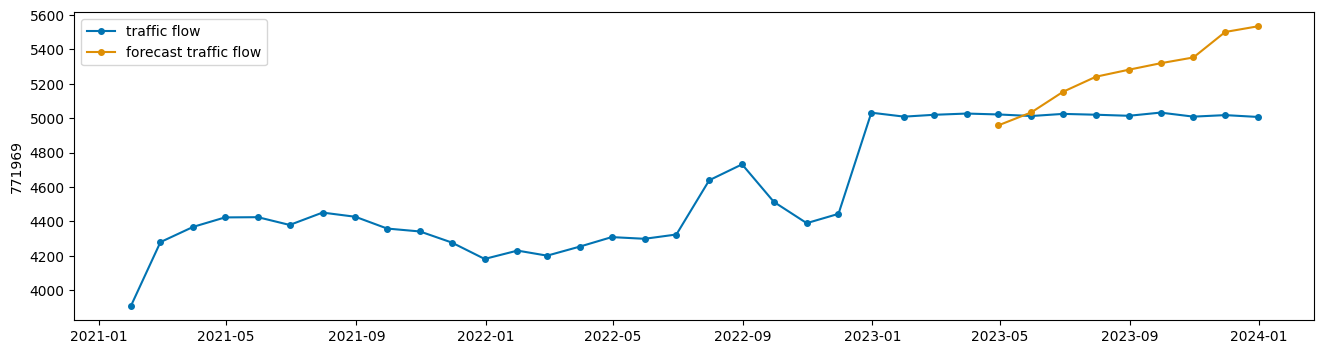

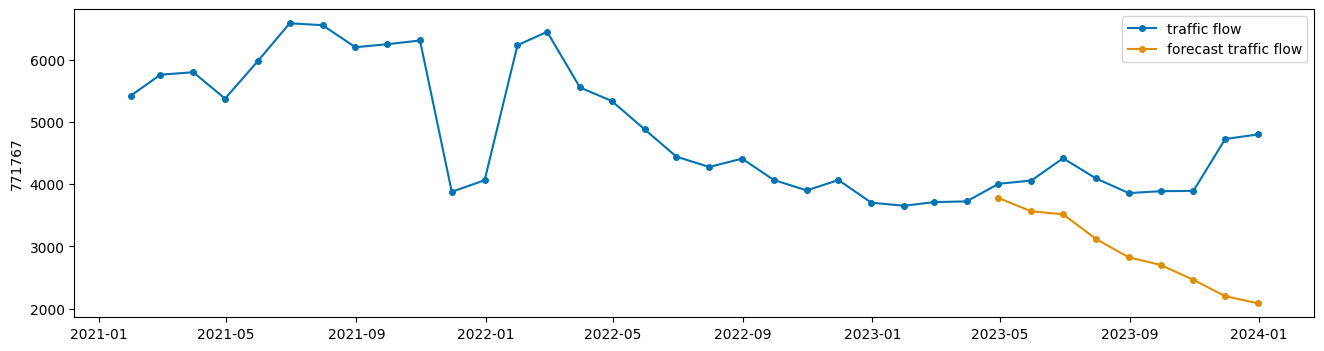

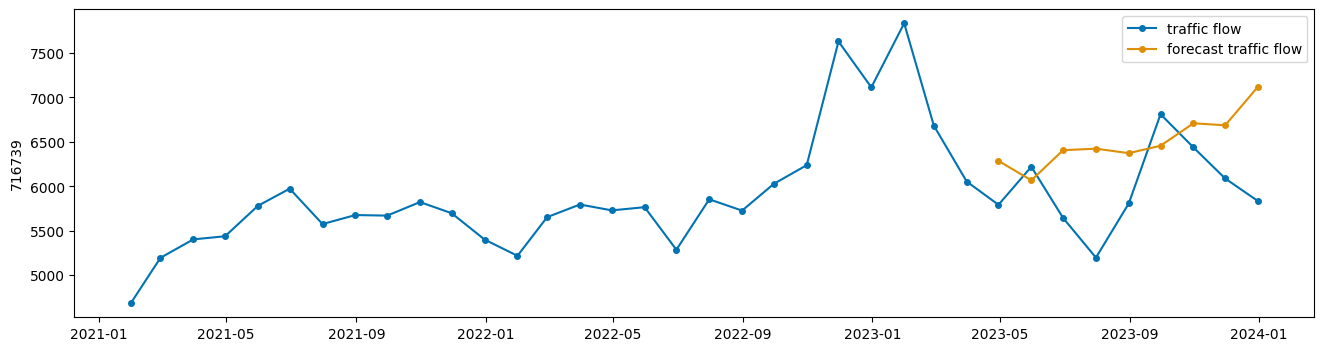

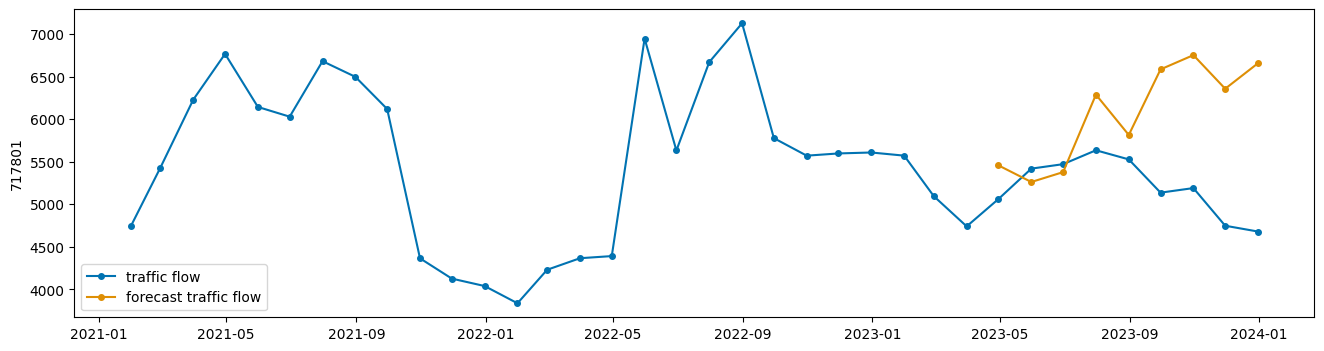

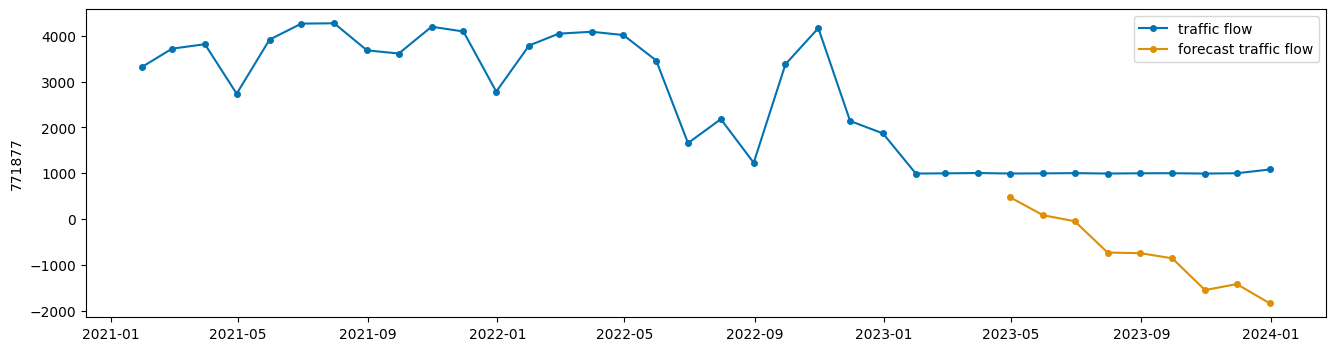

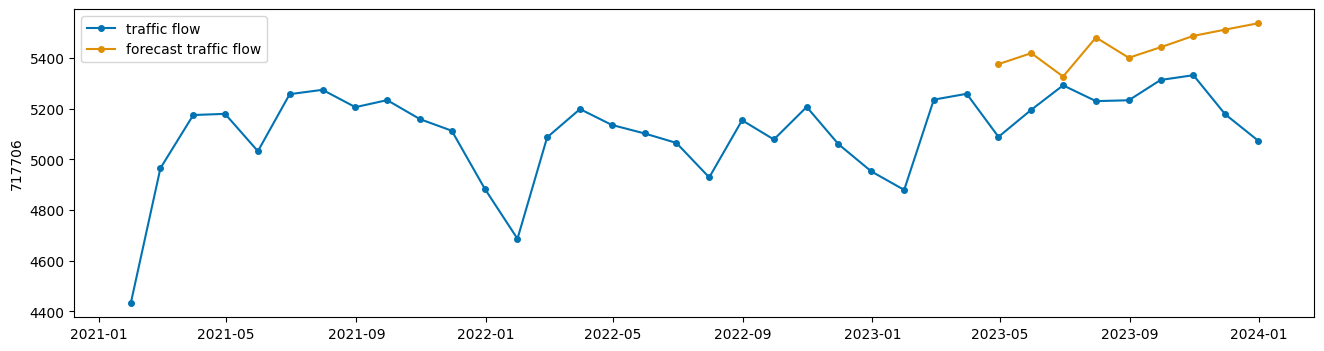

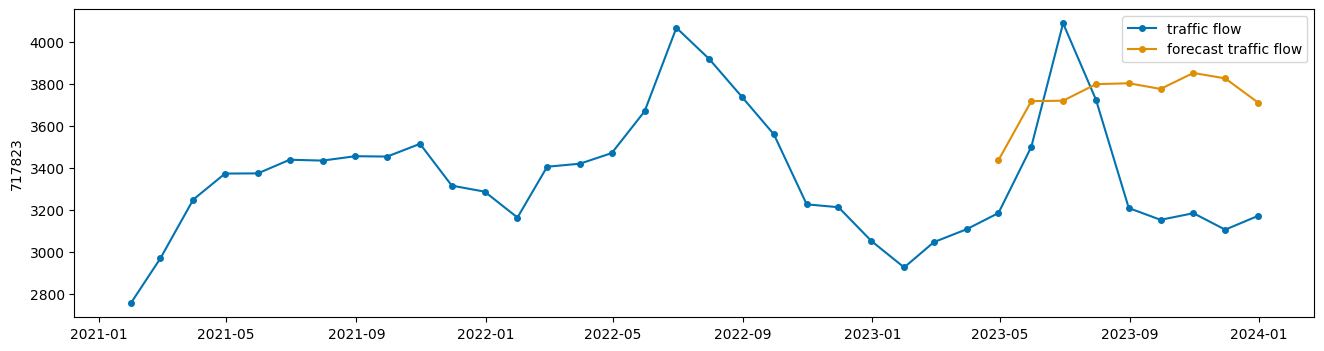

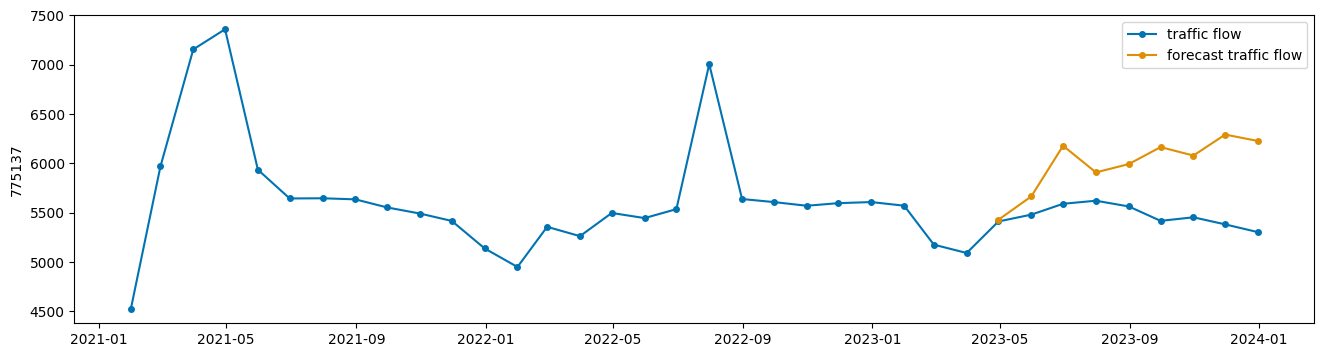

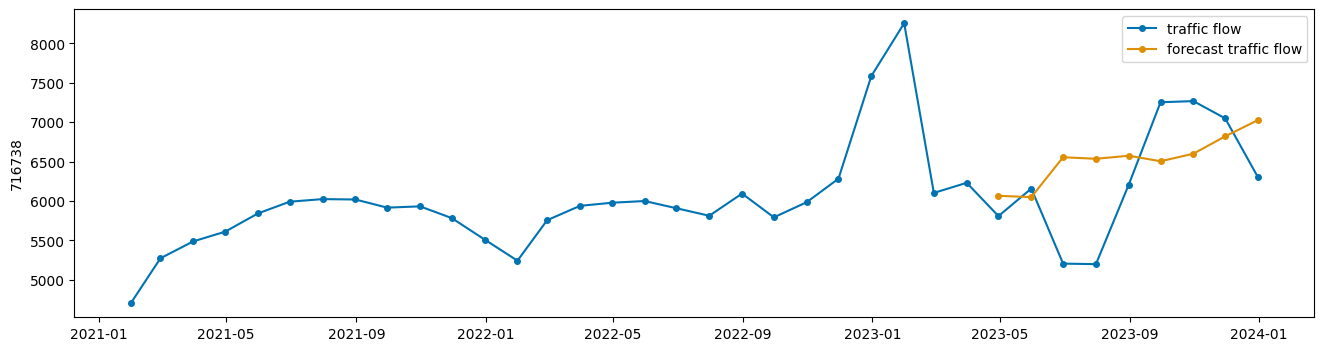

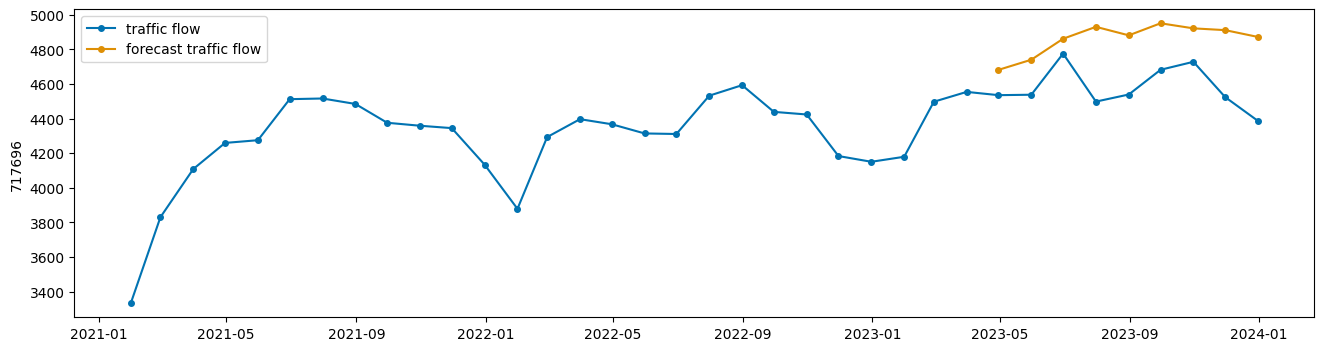

In [107]:
for station in sample_stations_m.columns:
    plot_series(sample_stations_m[station], forecast_var_m[station], labels= ['traffic flow', 'forecast traffic flow']);

In [108]:
print(f'RMSE: {root_mean_squared_error(y_test, preds)}')
print(f'MAE: {mean_absolute_error(y_test, preds)}')

RMSE: 510.43912889885803
MAE: 424.7998997672911


In [110]:
# weekly
sample_stations_w = sample_stations.resample('W').mean()
df_adfuller(sample_stations_w)

,station,p-value,1_diff_p_value,2_diff_p_value
0,771969,7.130871e-01,0.000021,NA
1,771767,5.943516e-02,0.000001,NA
2,716739,2.112393e-03,NA,NA
3,717801,1.461384e-01,0.0,NA
4,771877,3.233503e-01,0.0,NA
5,717706,1.249257e-13,NA,NA
6,717823,1.226881e-03,NA,NA
7,775137,4.440234e-03,NA,NA
8,716738,1.204898e-04,NA,NA
9,717696,1.022143e-04,NA,NA


In [112]:
var_w = pd.merge(df[['isholiday', 'temp', 'prcp', 'coco']].resample('W').mean(), sample_stations_w, how='inner', on='time')
var_w['771969_diff_1'] = sample_stations_w['771969'].diff()
var_w['771767_diff_1'] = sample_stations_w['771767'].diff()
var_w['717801_diff_1'] = sample_stations_w['717801'].diff()
var_w['771877_diff_1'] = sample_stations_w['771877'].diff()
var_w = var_w.drop(columns=['771969', '771767', '717801', '771877'])
var_w.dropna(inplace=True)
X = var_w.iloc[:,:4]
y = var_w.iloc[:,4:]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle = False)

In [116]:
model = VAR(maxlags=52, verbose=True)
model.fit(y_train, X_train)

/opt/anaconda3/envs/sktimeenv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


VAR(maxlags=52, verbose=True)

In [124]:
model.get_test_params()

[{'maxlags': 3}, {'trend': 'ctt'}]

In [120]:
preds_w = model.predict(y_test.index)
forecast_var_w = pd.DataFrame(data = preds_w, columns = y.columns, index = y_test.index)

In [121]:
# undifference the first-differenced columns
forecast_var_w['771969'] = sample_stations_w['771969'].iloc[-len(y_test)-1] + forecast_var_w['771969_diff_1'].cumsum()
forecast_var_w['771767'] = sample_stations_w['771767'].iloc[-len(y_test)-1] + forecast_var_w['771767_diff_1'].cumsum()
forecast_var_w['717801'] = sample_stations_w['717801'].iloc[-len(y_test)-1] + forecast_var_w['717801_diff_1'].cumsum()
forecast_var_w['771877'] = sample_stations_w['771877'].iloc[-len(y_test)-1] + forecast_var_w['771877_diff_1'].cumsum()
forecast_var_w.drop(columns=['771969_diff_1', '771767_diff_1', '717801_diff_1', '771877_diff_1'], inplace=True)

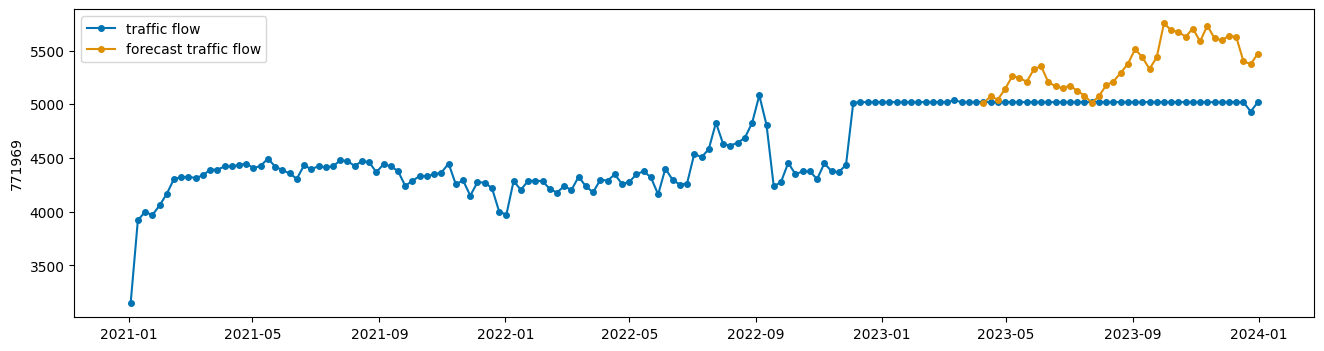

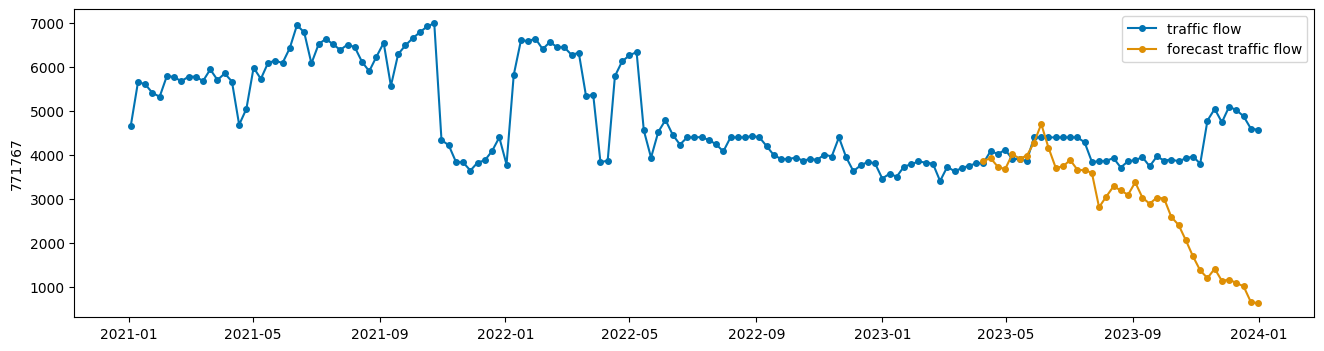

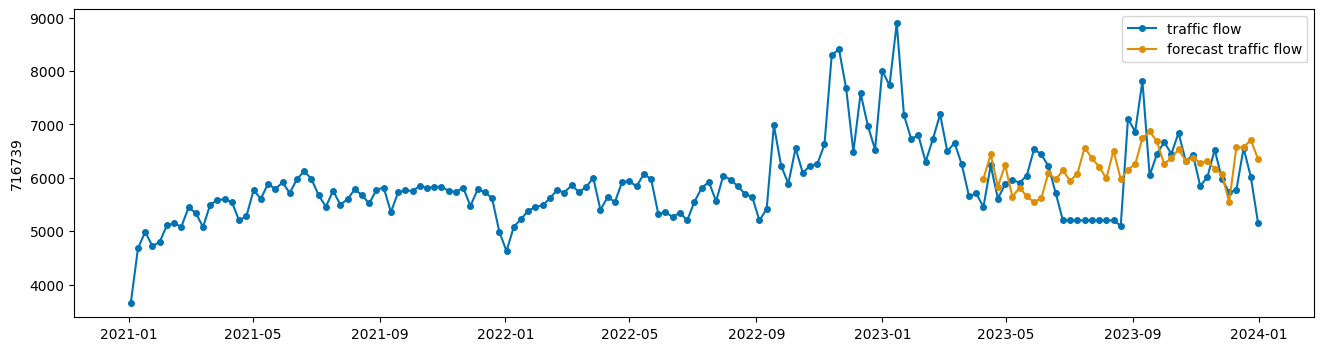

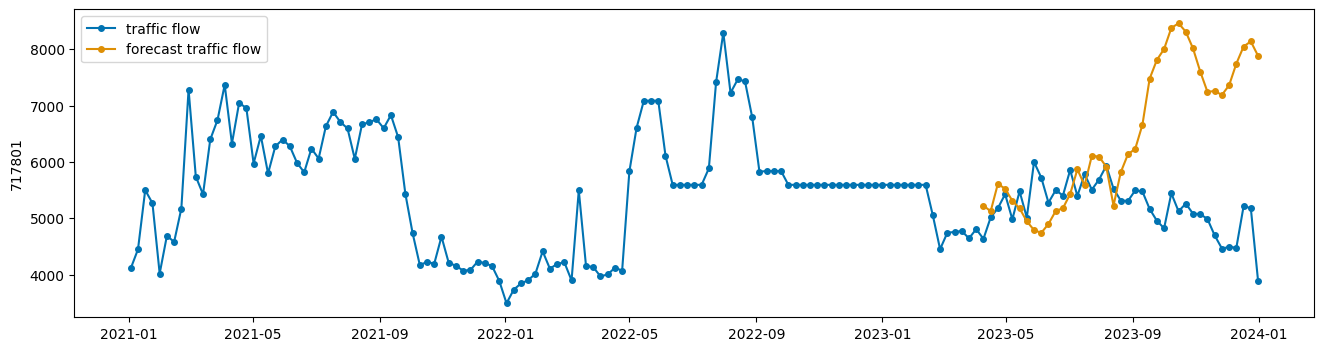

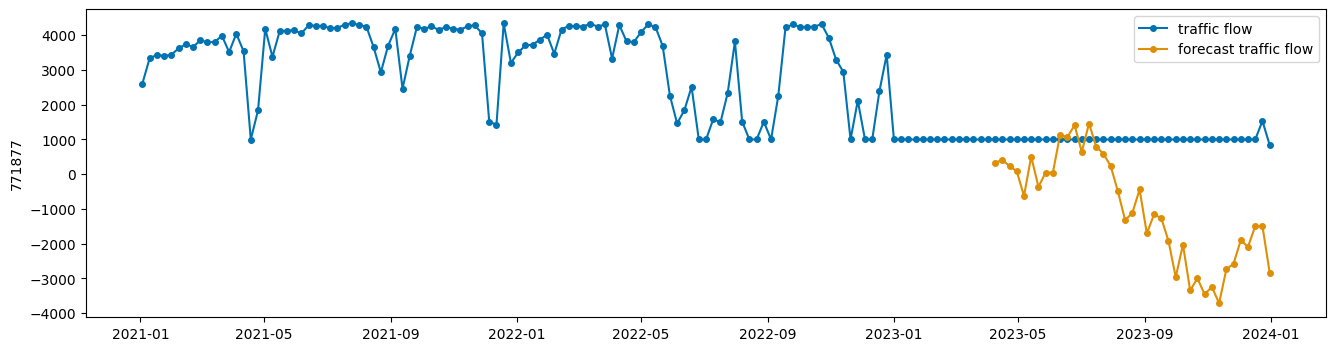

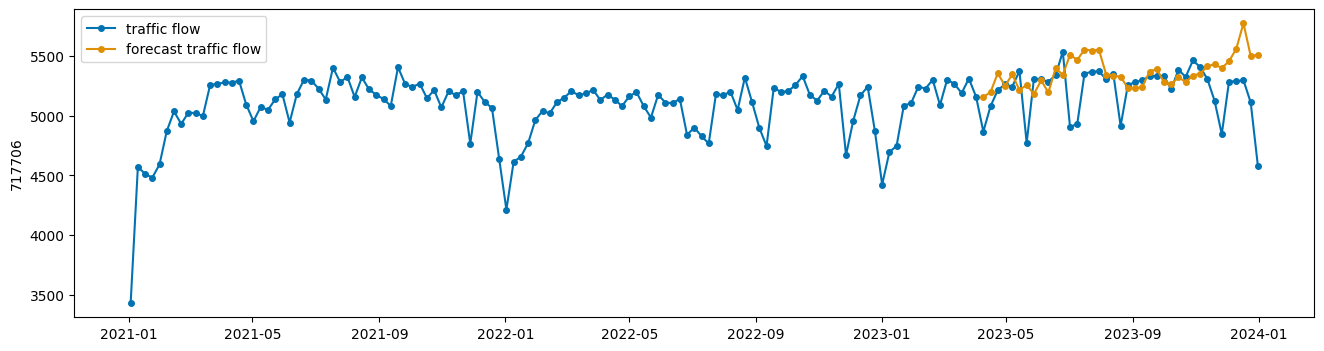

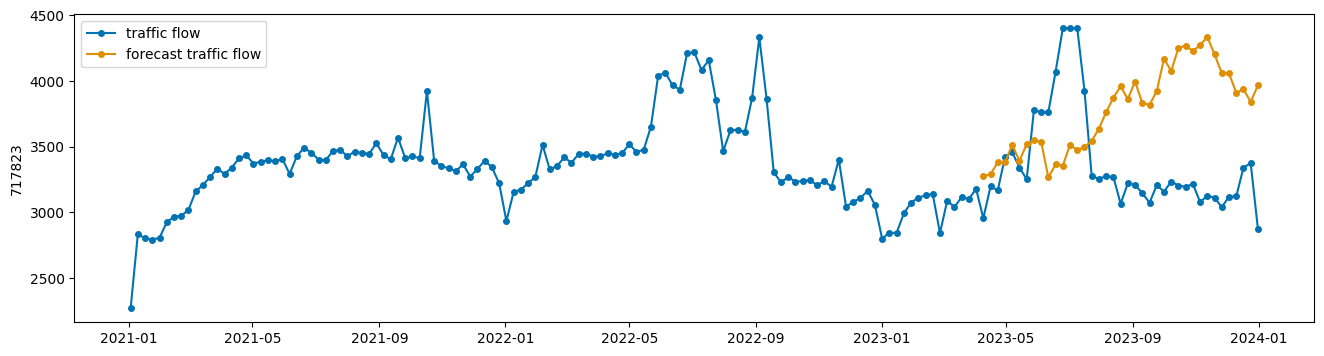

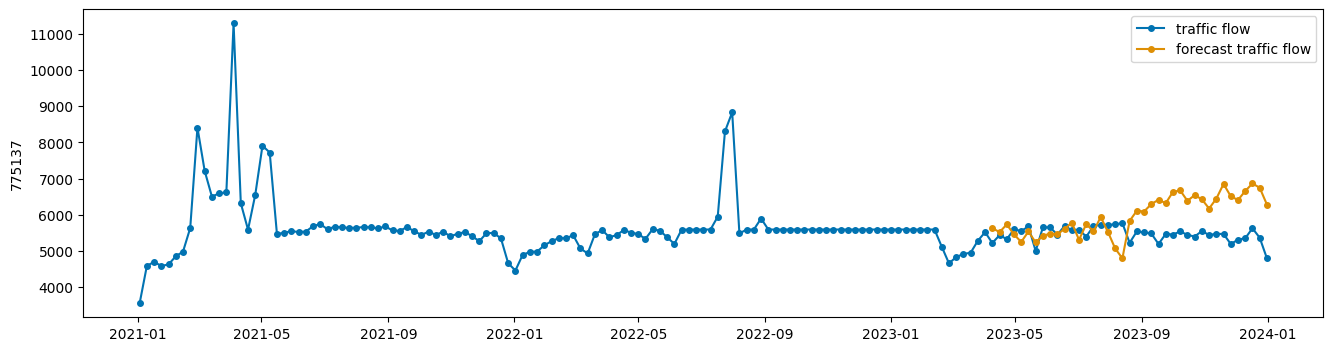

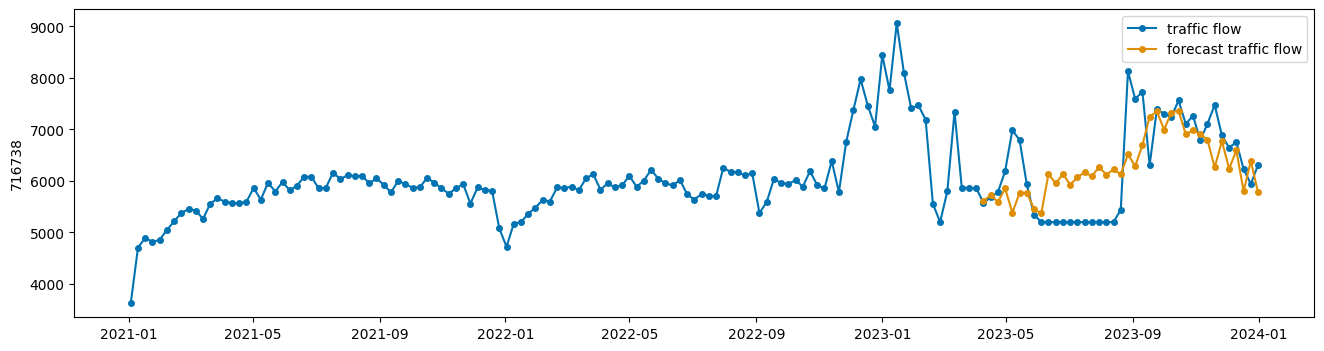

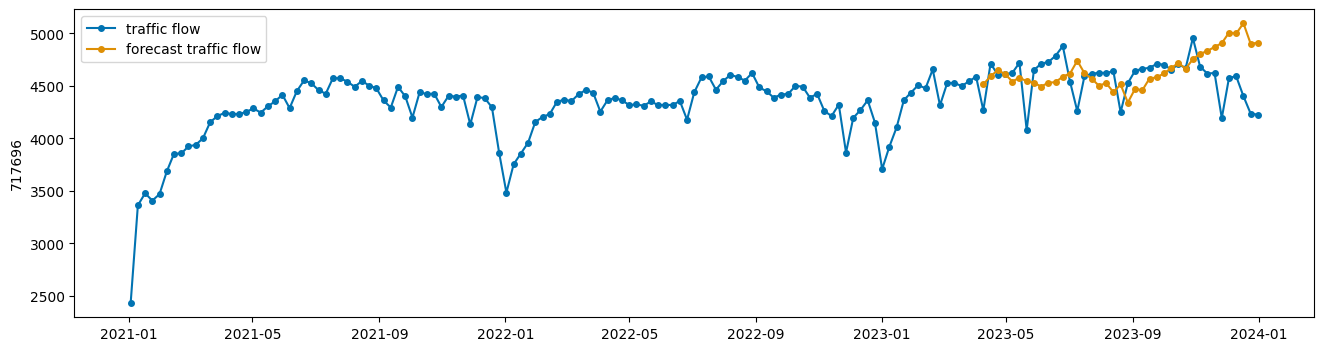

In [122]:
for station in sample_stations_w.columns:
    plot_series(sample_stations_w[station], forecast_var_w[station], labels= ['traffic flow', 'forecast traffic flow']);

In [123]:
print(f'RMSE: {root_mean_squared_error(y_test, preds_w)}')
print(f'MAE: {mean_absolute_error(y_test, preds_w)}')

RMSE: 518.112955232946
MAE: 421.54034890113115


In [125]:
# daily
sample_stations_d = sample_stations.resample('d').mean()
df_adfuller(sample_stations_d)

,station,p-value,1_diff_p_value,2_diff_p_value
0,771969,0.463654,0.0,NA
1,771767,0.077679,0.0,NA
2,716739,0.010292,NA,NA
3,717801,0.090348,0.0,NA
4,771877,0.205028,0.0,NA
5,717706,0.000013,NA,NA
6,717823,0.011268,NA,NA
7,775137,0.000142,NA,NA
8,716738,0.007543,NA,NA
9,717696,0.001262,NA,NA


In [126]:
var_d = pd.merge(df[['isholiday', 'temp', 'prcp', 'coco']].resample('d').mean(), sample_stations_d, how='inner', on='time')
var_d['771969_diff_1'] = sample_stations_d['771969'].diff()
var_d['771767_diff_1'] = sample_stations_d['771767'].diff()
var_d['717801_diff_1'] = sample_stations_d['717801'].diff()
var_d['771877_diff_1'] = sample_stations_d['771877'].diff()
var_d = var_d.drop(columns=['771969', '771767', '717801', '771877'])
var_d.dropna(inplace=True)
X = var_d.iloc[:,:4]
y = var_d.iloc[:,4:]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle = False)

In [127]:
model = VAR(maxlags=30, verbose=True)
model.fit(y_train, X_train)

/opt/anaconda3/envs/sktimeenv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


VAR(maxlags=30, verbose=True)

In [128]:
model.get_test_params()

[{'maxlags': 3}, {'trend': 'ctt'}]

In [129]:
preds_d = model.predict(y_test.index)
forecast_var_d = pd.DataFrame(data = preds_d, columns = y.columns, index = y_test.index)

In [130]:
# undifference the first-differenced columns
forecast_var_d['771969'] = sample_stations_d['771969'].iloc[-len(y_test)-1] + forecast_var_d['771969_diff_1'].cumsum()
forecast_var_d['771767'] = sample_stations_d['771767'].iloc[-len(y_test)-1] + forecast_var_d['771767_diff_1'].cumsum()
forecast_var_d['717801'] = sample_stations_d['717801'].iloc[-len(y_test)-1] + forecast_var_d['717801_diff_1'].cumsum()
forecast_var_d['771877'] = sample_stations_d['771877'].iloc[-len(y_test)-1] + forecast_var_d['771877_diff_1'].cumsum()
forecast_var_d.drop(columns=['771969_diff_1', '771767_diff_1', '717801_diff_1', '771877_diff_1'], inplace=True)

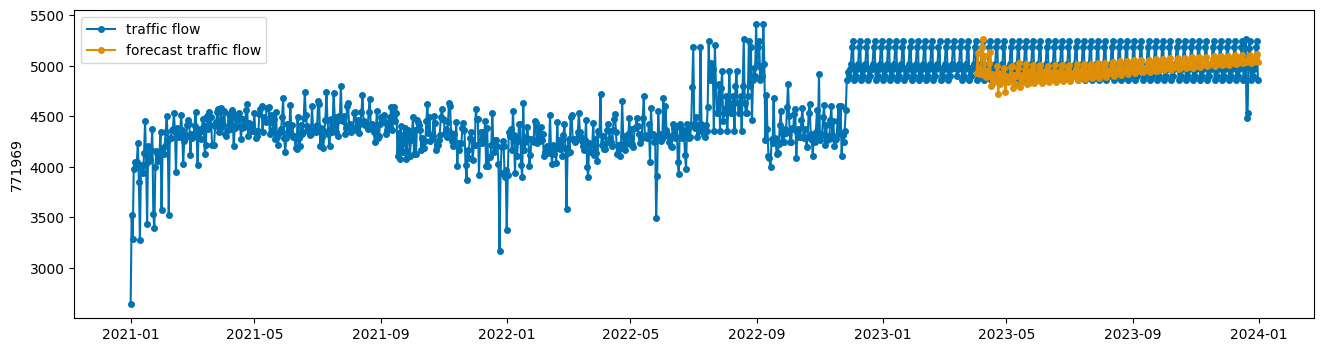

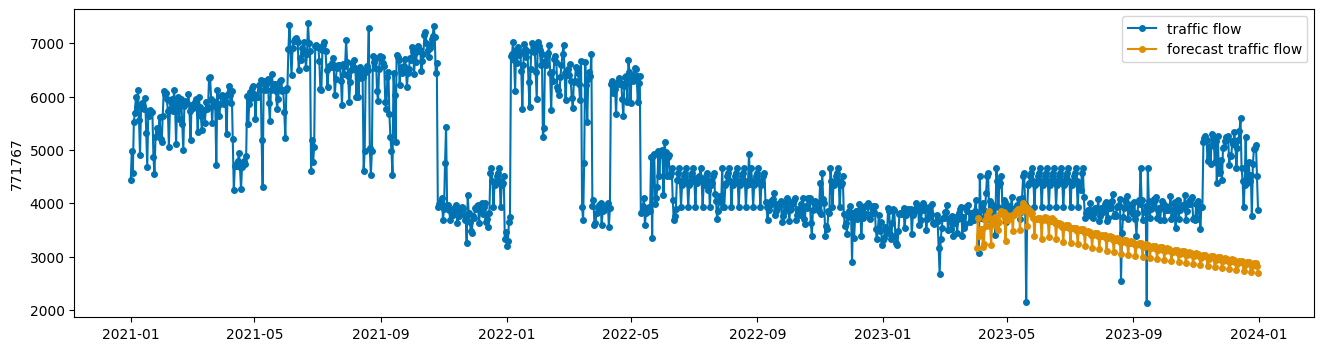

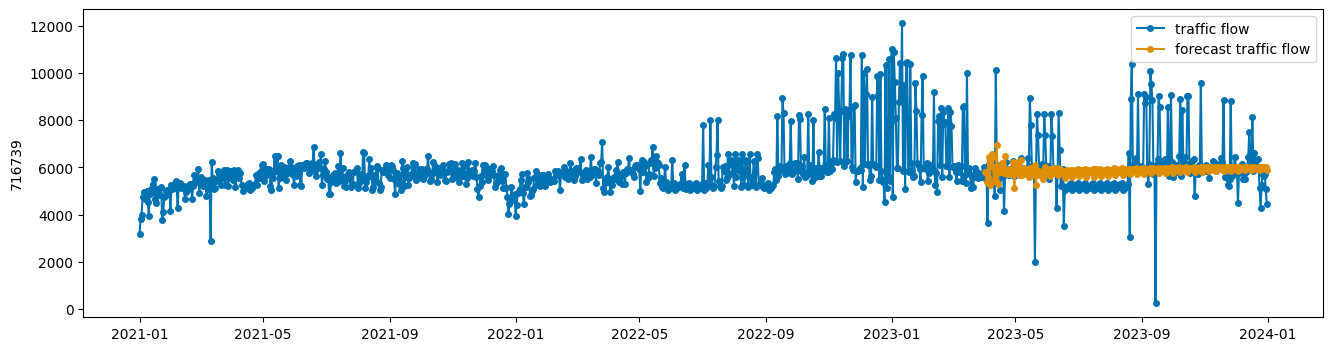

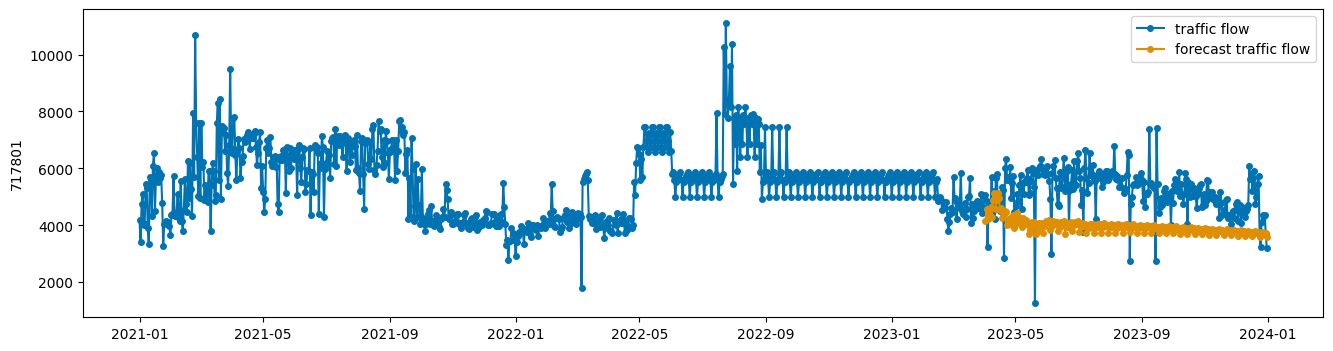

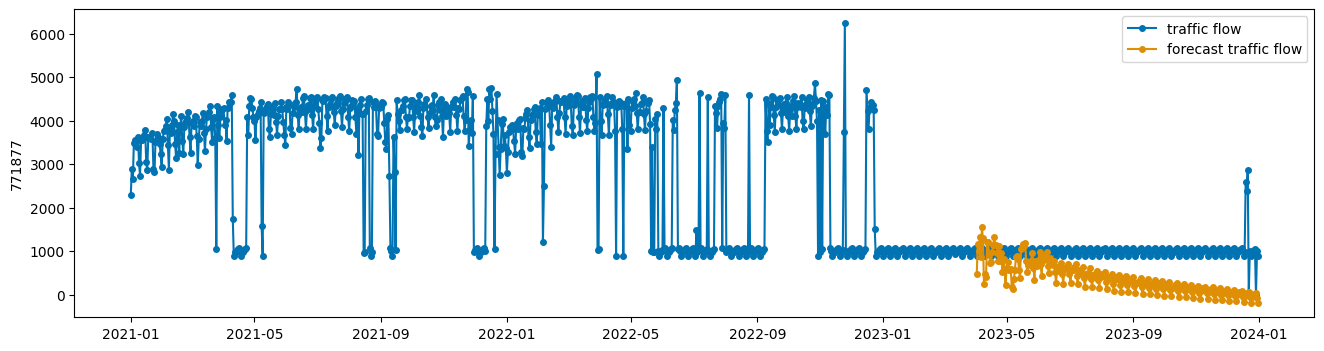

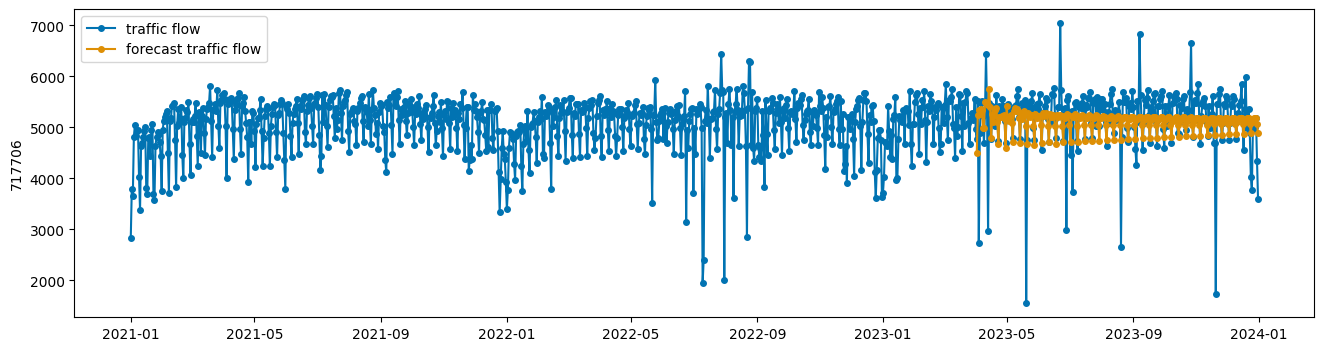

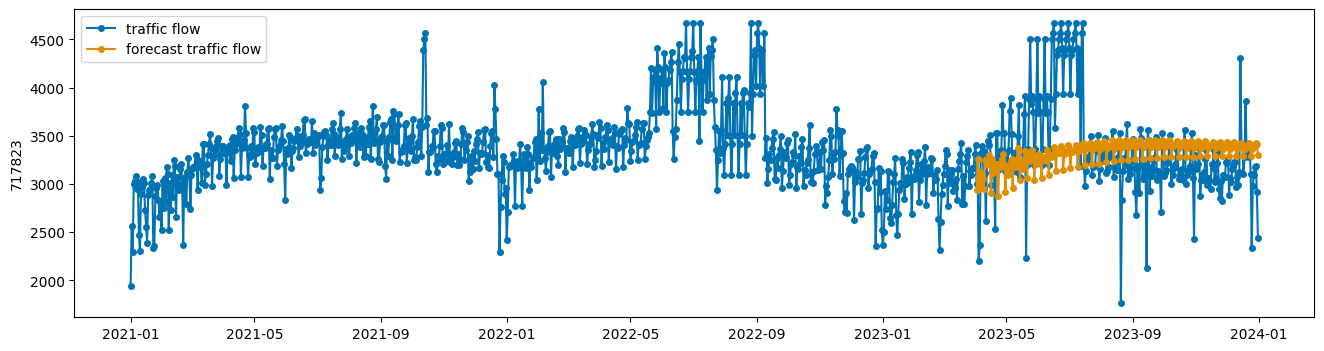

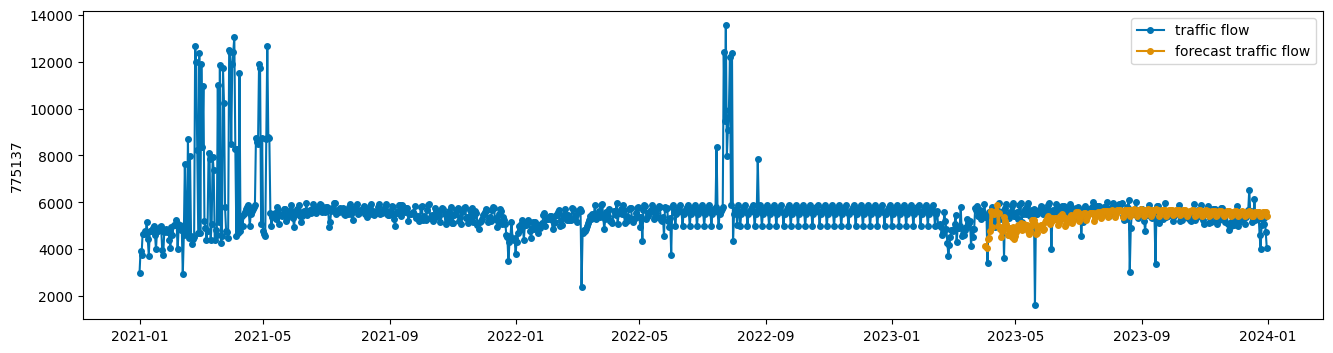

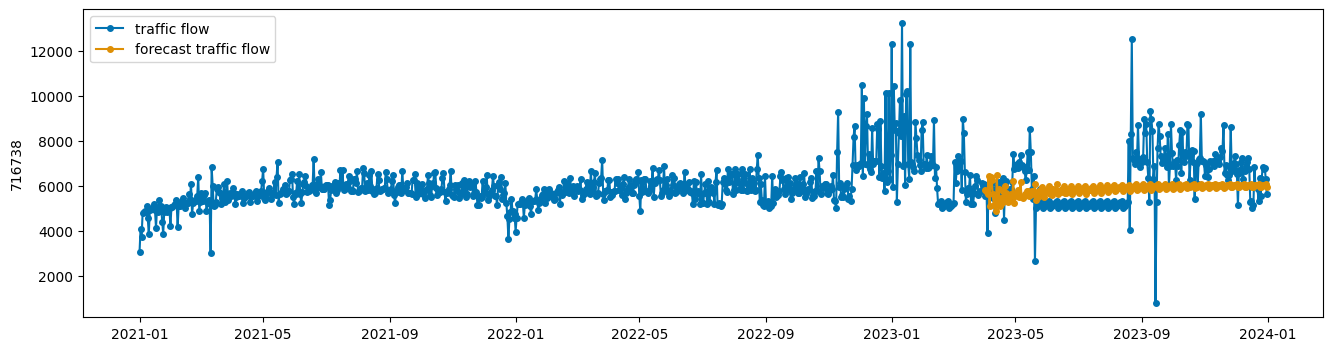

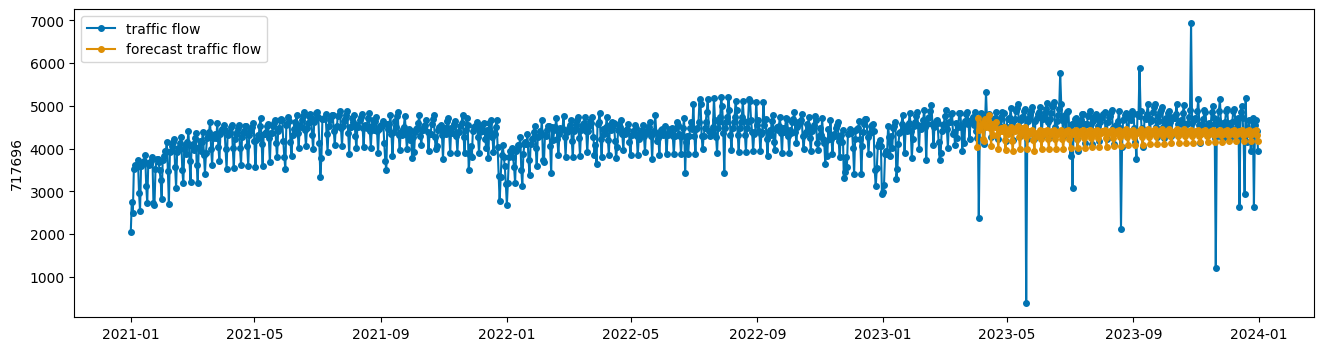

In [132]:
for station in sample_stations_d.columns:
    plot_series(sample_stations_d[station], forecast_var_d[station], labels= ['traffic flow', 'forecast traffic flow']);

In [131]:
print(f'RMSE: {root_mean_squared_error(y_test, preds_d)}')
print(f'MAE: {mean_absolute_error(y_test, preds_d)}')

RMSE: 628.5647717557681
MAE: 410.7332548461548


In [133]:
# hourly
df_adfuller(sample_stations)

,station,p-value,1_diff_p_value,2_diff_p_value
0,771969,8.108330e-11,NA,NA
1,771767,4.105735e-06,NA,NA
2,716739,4.184550e-25,NA,NA
3,717801,1.831673e-12,NA,NA
4,771877,3.449745e-08,NA,NA
5,717706,0.000000e+00,NA,NA
6,717823,1.243041e-16,NA,NA
7,775137,1.041955e-21,NA,NA
8,716738,1.669286e-18,NA,NA
9,717696,1.354000e-28,NA,NA


In [134]:
var_h = pd.merge(df[['isholiday', 'temp', 'prcp', 'coco']], sample_stations, how='inner', on='time')
X = var_h.iloc[:,:4]
y = var_h.iloc[:,4:]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle = False)

In [135]:
model = VAR(maxlags=24, verbose=True)
model.fit(y_train, X_train)

/opt/anaconda3/envs/sktimeenv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


VAR(maxlags=24, verbose=True)

In [136]:
model.get_test_params()

[{'maxlags': 3}, {'trend': 'ctt'}]

In [137]:
preds_h = model.predict(y_test.index)
forecast_var_h = pd.DataFrame(data = preds_h, columns = y.columns, index = y_test.index)

In [ ]:
for station in sample_stations.columns:
    plot_series(sample_stations[station], forecast_var_h[station], labels= ['traffic flow', 'forecast traffic flow']);

In [140]:
print(f'RMSE: {root_mean_squared_error(y_test, preds_h)}')
print(f'MAE: {mean_absolute_error(y_test, preds_h)}')

RMSE: 2081.8307673809595
MAE: 1772.0427094701051


### 3.2 Prophet

In [22]:
# prepare dataframe for prophet
prophet_df = pd.merge(sample_stations, df[['isholiday', 'temp', 'prcp', 'coco']], how='inner', on='time')
prophet_df = prophet_df.reset_index()
prophet_df.rename(columns={'time': 'ds', '771969': 'y'}, inplace=True)
prophet_df.head()

,ds,y,771767,716739,717801,771877,717706,717823,775137,716738,717696,isholiday,temp,prcp,coco
0,2021-01-01 00:00:00,1161.0,3291.0,2039.0,2559.0,1224.0,1190.0,1072.0,1612.0,1589.0,846.0,1,17.8,0.0,2.0
1,2021-01-01 01:00:00,1266.0,3487.0,2146.0,2968.0,1201.0,1144.0,1151.0,1727.0,1754.0,880.0,1,16.7,0.0,2.0
2,2021-01-01 02:00:00,857.0,2938.0,1649.0,2504.0,942.0,722.0,808.0,1080.0,1154.0,609.0,1,16.1,0.0,2.0
3,2021-01-01 03:00:00,584.0,2506.0,1323.0,2128.0,847.0,558.0,541.0,668.0,720.0,403.0,1,16.1,0.0,2.0
4,2021-01-01 04:00:00,614.0,2557.0,1228.0,2105.0,888.0,582.0,503.0,612.0,597.0,473.0,1,15.0,0.0,1.0


In [51]:
df

,isholiday,temp,dwpt,rhum,prcp,wdir,wspd,pres,coco,771826,...,767351,717819,717823,767367,717825,717827,771808,771767,772011,772024
time,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,1,17.8,0.0,30.0,0.0,350.0,24.1,1013.0,2.0,690.0,...,1391.0,1147.0,1072.0,1407.0,1142.0,1107.0,2530.0,3291.0,675.0,743.0
2021-01-01 01:00:00,1,16.7,-0.1,32.0,0.0,340.0,24.1,1013.1,2.0,793.0,...,1537.0,1248.0,1151.0,1445.0,1190.0,1140.0,2655.0,3487.0,733.0,801.0
2021-01-01 02:00:00,1,16.1,-0.6,32.0,0.0,330.0,25.9,1013.9,2.0,463.0,...,1164.0,873.0,808.0,1037.0,855.0,823.0,2238.0,2938.0,449.0,541.0
2021-01-01 03:00:00,1,16.1,-1.0,31.0,0.0,330.0,22.3,1014.0,2.0,347.0,...,862.0,585.0,541.0,642.0,544.0,551.0,1813.0,2506.0,327.0,408.0
2021-01-01 04:00:00,1,15.0,-1.6,32.0,0.0,320.0,20.5,1013.9,1.0,388.0,...,753.0,501.0,503.0,561.0,476.0,448.0,1711.0,2557.0,286.0,454.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,0,15.0,9.4,69.0,0.0,86.0,6.0,1021.0,3.0,5138.0,...,3811.0,3646.0,3561.0,3952.0,5138.0,5025.0,4715.0,5658.0,2289.0,2892.0
2023-12-31 20:00:00,0,15.0,10.0,72.0,0.0,40.0,7.0,1020.0,3.0,5011.0,...,3331.0,3203.0,3011.0,3567.0,5011.0,4586.0,4085.0,5097.0,1814.0,2424.0
2023-12-31 21:00:00,0,15.0,10.0,72.0,0.0,110.0,7.0,1019.0,3.0,4732.0,...,2939.0,2763.0,2546.0,3139.0,4732.0,3677.0,3226.0,4128.0,1460.0,1922.0


In [100]:
# monthly
prophet_df_m = prophet_df.set_index('ds').copy()
prophet_df_m = prophet_df_m.resample('ME').mean()
prophet_df_m.reset_index(inplace=True)

In [101]:
train, test = train_test_split(prophet_df_m, test_size = 0.25, shuffle = False)

In [102]:
model = Prophet()
# add other columns as regressors 
for i in prophet_df_m.iloc[:,2:].columns:
    model.add_regressor(i)

In [103]:
model.fit(train)

02:37:57 - cmdstanpy - INFO - Chain [1] start processing
02:37:58 - cmdstanpy - INFO - Chain [1] done processing


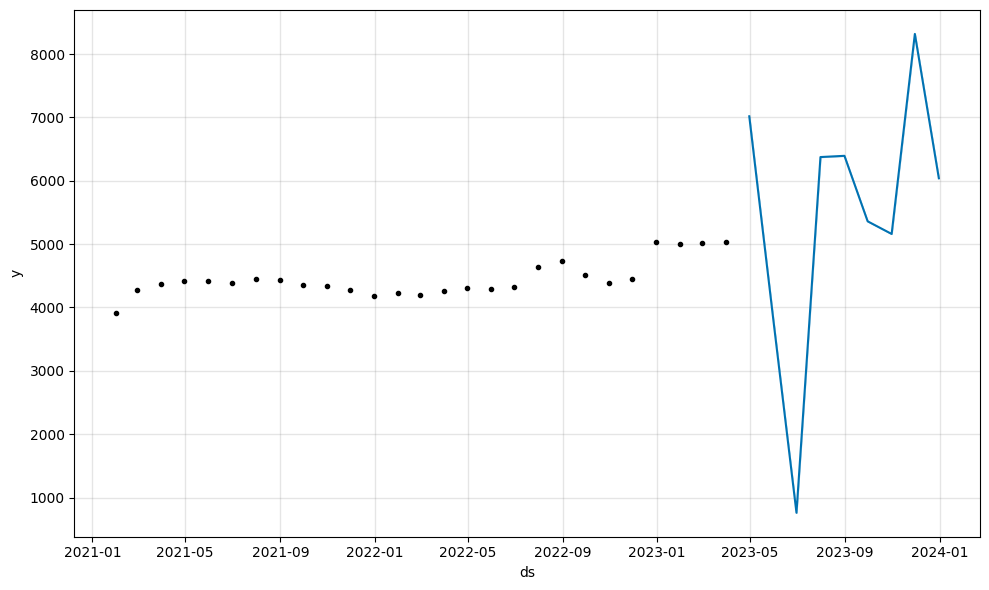

In [104]:
forecast_m = model.predict(test.drop(columns=['y']))
fig = model.plot(forecast_m);

In [77]:
print(f"RMSE: {root_mean_squared_error(test['y'], forecast_m['yhat'])}")
print(f"MAE: {mean_absolute_error(test['y'], forecast_m['yhat'])}")

RMSE: 2092.8735590465867
MAE: 1666.747484301731


In [78]:
# weekly

In [105]:
prophet_df_w = prophet_df.set_index('ds').copy()
prophet_df_w = prophet_df_w.resample('W').mean()
prophet_df_w.reset_index(inplace=True)
train, test = train_test_split(prophet_df_w, test_size = 0.25, shuffle = False)

In [106]:
model = Prophet()

# add other columns as regressors 
for i in prophet_df_w.iloc[:,2:].columns:
    model.add_regressor(i)

In [107]:
model.fit(train)

02:38:04 - cmdstanpy - INFO - Chain [1] start processing
02:38:04 - cmdstanpy - INFO - Chain [1] done processing


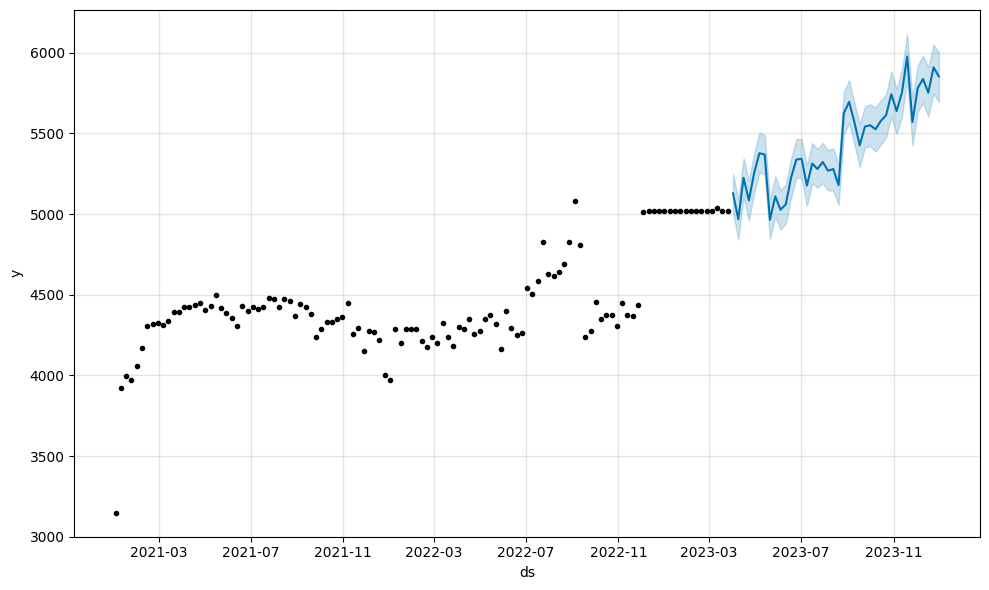

In [108]:
forecast_w = model.predict(test.drop(columns=['y']))
fig = model.plot(forecast_w);

In [109]:
print(f"RMSE: {root_mean_squared_error(test['y'], forecast_w['yhat'])}")
print(f"MAE: {mean_absolute_error(test['y'], forecast_w['yhat'])}")

RMSE: 497.30507773714055
MAE: 418.0884282209204


In [ ]:
# daily

In [110]:
prophet_df_d = prophet_df.set_index('ds').copy()
prophet_df_d = prophet_df_d.resample('d').mean()
prophet_df_d.reset_index(inplace=True)
train, test = train_test_split(prophet_df_d, test_size = 0.25, shuffle = False)

In [111]:
model = Prophet()

# add other columns as regressors 
for i in prophet_df_d.iloc[:,2:].columns:
    model.add_regressor(i)

In [112]:
model.fit(train)

02:38:11 - cmdstanpy - INFO - Chain [1] start processing
02:38:12 - cmdstanpy - INFO - Chain [1] done processing


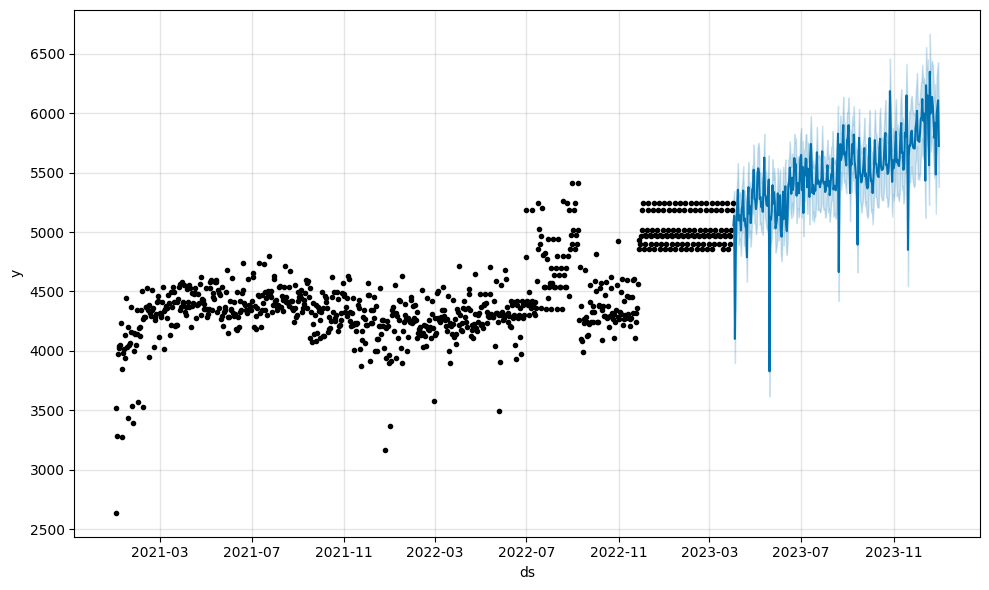

In [113]:
forecast_d = model.predict(test.drop(columns=['y']))
fig = model.plot(forecast_d);

In [114]:
print(f"RMSE: {root_mean_squared_error(test['y'], forecast_d['yhat'])}")
print(f"MAE: {mean_absolute_error(test['y'], forecast_d['yhat'])}")

RMSE: 564.8785924042244
MAE: 499.31969312617485


In [ ]:
# hourly

In [91]:
train, test = train_test_split(prophet_df, test_size = 0.25, shuffle = False)

In [92]:
model = Prophet()
for i in prophet_df.iloc[:,2:].columns:
    model.add_regressor(i)

In [93]:
model.fit(train)

02:36:36 - cmdstanpy - INFO - Chain [1] start processing
02:36:42 - cmdstanpy - INFO - Chain [1] done processing


In [94]:
forecast_h = model.predict(test.drop(columns=['y']))

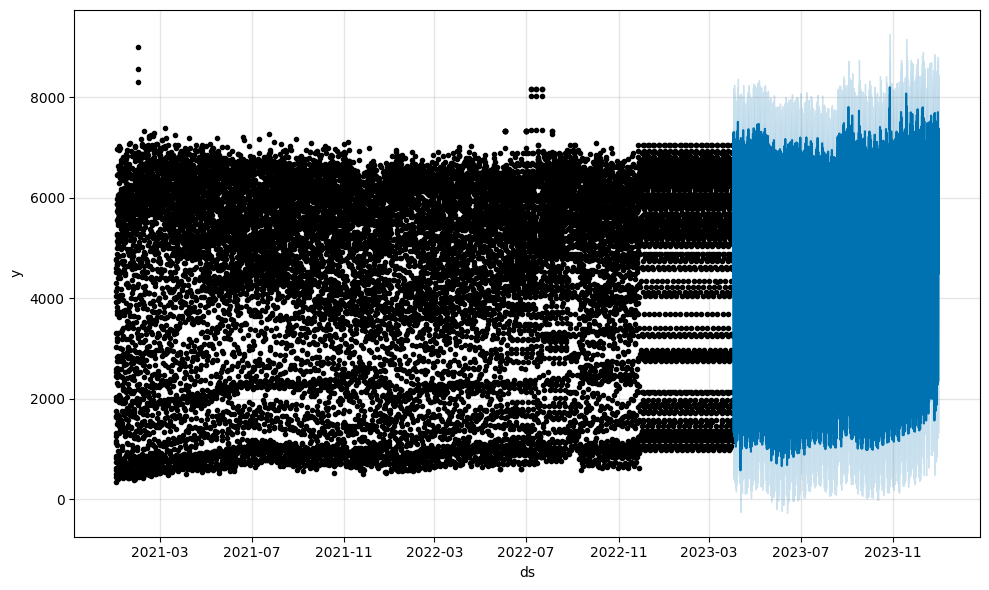

In [97]:
fig = model.plot(forecast_h)

In [98]:
print(f"RMSE: {root_mean_squared_error(test['y'], forecast_h['yhat'])}")
print(f"MAE: {mean_absolute_error(test['y'], forecast_h['yhat'])}")

RMSE: 601.0359153874049
MAE: 432.0534049317946


In [115]:
forecast_h

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,716738,716738_lower,716738_upper,716739,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-04-02 06:00:00,4907.506036,3191.050345,5042.555856,4907.506036,4907.506036,-450.162402,-450.162402,-450.162402,251.158327,...,209.147933,209.147933,209.147933,121.217998,121.217998,121.217998,0.0,0.0,0.0,4094.519717
1,2023-04-02 07:00:00,4907.559747,3249.243265,4975.593377,4907.559747,4907.559747,-278.286800,-278.286800,-278.286800,159.538498,...,208.387126,208.387126,208.387126,121.328574,121.328574,121.328574,0.0,0.0,0.0,4168.536984
2,2023-04-02 08:00:00,4907.613459,3475.675977,5352.257307,4907.613459,4907.613459,-251.916205,-251.916205,-251.916205,142.892454,...,207.154065,207.154065,207.154065,121.437237,121.437237,121.437237,0.0,0.0,0.0,4429.926662
3,2023-04-02 09:00:00,4907.667171,4556.200883,6362.404073,4907.667171,4907.667171,-26.715994,-26.715994,-26.715994,18.646378,...,205.447969,205.447969,205.447969,121.543981,121.543981,121.543981,0.0,0.0,0.0,5417.976019
4,2023-04-02 10:00:00,4907.720883,5489.352800,7249.857370,4907.720883,4907.720883,137.458461,137.458461,137.458461,-87.688554,...,203.269953,203.269953,203.269953,121.648799,121.648799,121.648799,0.0,0.0,0.0,6343.108887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6565,2023-12-31 19:00:00,5260.123917,5680.607085,7990.148937,4661.373381,5917.422795,189.849598,189.849598,189.849598,-23.634575,...,163.601304,163.601304,163.601304,246.834386,246.834386,246.834386,0.0,0.0,0.0,6819.110109
6566,2023-12-31 20:00:00,5260.177629,5473.654703,7671.804021,4661.249064,5917.479873,136.291620,136.291620,136.291620,17.114942,...,157.204205,157.204205,157.204205,246.883532,246.883532,246.883532,0.0,0.0,0.0,6487.169507
6567,2023-12-31 21:00:00,5260.231341,5020.585806,7275.140721,4661.124747,5917.536950,50.645529,50.645529,50.645529,60.194905,...,150.478313,150.478313,150.478313,246.932196,246.932196,246.932196,0.0,0.0,0.0,6157.558489
6568,2023-12-31 22:00:00,5260.285053,4560.952243,6700.687931,4661.018791,5917.607136,-16.097746,-16.097746,-16.097746,86.495655,...,143.447662,143.447662,143.447662,246.980377,246.980377,246.980377,0.0,0.0,0.0,5577.367485
